In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install OpenAI's CLIP and small helper libraries
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-y3za5e9c
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-y3za5e9c
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369549 sha256=1c9d7dcb41271d9caf67cf3758dbfaaba29409294a1c28f5dd737e4a05ca4e37
  Stored in directory: /tmp/pip-ephem-wheel-cache-n00h4vrk/wheels/cb/a8/74/5f32d6cf0407457f0f62737b6da5c14eb86b9cac476fdf630d
Successfully built clip


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

CUDA available: True
Using device: cuda


In [ ]:
import clip

model, preprocess = clip.load("ViT-B/32", device=device) # ViT-B/32 is the smallest, fastest CLIP model

print("CLIP model loaded")

CLIP model loaded


In [ ]:
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x787d63c5a660>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_token = "...."

with open("/root/.kaggle/access_token", "w") as f:
    f.write(kaggle_token)

os.system("chmod 600 /root/.kaggle/access_token")

print("Kaggle token saved")

Kaggle token saved


In [ ]:
# Download the dataset
!kaggle datasets download -d iamsouravbanerjee/animal-image-dataset-90-different-animals

# Unzip it into a folder called "animals_data"
!unzip -q animal-image-dataset-90-different-animals.zip -d animals_data

print("done")

Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals
License(s): other
100% 656M/656M [00:05<00:00, 125MB/s]

replace animals_data/animals/animals/antelope/02f4b3be2d.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: done


In [ ]:
data_root = "animals_data"
print(os.listdir(data_root))

['name of the animals.txt', 'animals']


In [ ]:
inner_path = "animals_data/animals"
print("Contents of animals_data/animals-->", os.listdir(inner_path))

Contents of animals_data/animals--> ['animals']


In [ ]:
data_path = "animals_data/animals/animals"
species_folders = sorted(os.listdir(data_path))
print("Number of species folders:", len(species_folders))
print("First 10:", species_folders[:10])

Number of species folders: 90
First 10: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat']


In [ ]:
species_folders

['antelope',
 'badger',
 'bat',
 'bear',
 'bee',
 'beetle',
 'bison',
 'boar',
 'butterfly',
 'cat',
 'caterpillar',
 'chimpanzee',
 'cockroach',
 'cow',
 'coyote',
 'crab',
 'crow',
 'deer',
 'dog',
 'dolphin',
 'donkey',
 'dragonfly',
 'duck',
 'eagle',
 'elephant',
 'flamingo',
 'fly',
 'fox',
 'goat',
 'goldfish',
 'goose',
 'gorilla',
 'grasshopper',
 'hamster',
 'hare',
 'hedgehog',
 'hippopotamus',
 'hornbill',
 'horse',
 'hummingbird',
 'hyena',
 'jellyfish',
 'kangaroo',
 'koala',
 'ladybugs',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'mosquito',
 'moth',
 'mouse',
 'octopus',
 'okapi',
 'orangutan',
 'otter',
 'owl',
 'ox',
 'oyster',
 'panda',
 'parrot',
 'pelecaniformes',
 'penguin',
 'pig',
 'pigeon',
 'porcupine',
 'possum',
 'raccoon',
 'rat',
 'reindeer',
 'rhinoceros',
 'sandpiper',
 'seahorse',
 'seal',
 'shark',
 'sheep',
 'snake',
 'sparrow',
 'squid',
 'squirrel',
 'starfish',
 'swan',
 'tiger',
 'turkey',
 'turtle',
 'whale',
 'wolf',
 'wombat',
 'woodpecker',


In [ ]:
# mapping: species -> diet category

diet_map = {
    # Herbivore
    "antelope": "Herbivore", "bison": "Herbivore", "cow": "Herbivore",
    "deer": "Herbivore", "donkey": "Herbivore", "elephant": "Herbivore",
    "goat": "Herbivore", "goose": "Herbivore", "hare": "Herbivore",
    "hippopotamus": "Herbivore", "horse": "Herbivore", "kangaroo": "Herbivore",
    "koala": "Herbivore", "okapi": "Herbivore", "ox": "Herbivore",
    "panda": "Herbivore", "porcupine": "Herbivore", "reindeer": "Herbivore",
    "rhinoceros": "Herbivore", "sheep": "Herbivore", "swan": "Herbivore",
    "wombat": "Herbivore", "zebra": "Herbivore",

    # Carnivore
    "cat": "Carnivore", "coyote": "Carnivore", "dolphin": "Carnivore",
    "eagle": "Carnivore", "fox": "Carnivore", "hyena": "Carnivore",
    "leopard": "Carnivore", "lion": "Carnivore", "octopus": "Carnivore",
    "otter": "Carnivore", "owl": "Carnivore", "penguin": "Carnivore",
    "seal": "Carnivore", "shark": "Carnivore", "snake": "Carnivore",
    "tiger": "Carnivore", "wolf": "Carnivore",

    # Omnivore
    "badger": "Omnivore", "bear": "Omnivore", "boar": "Omnivore",
    "chimpanzee": "Omnivore", "crow": "Omnivore", "hamster": "Omnivore",
    "hornbill": "Omnivore", "mouse": "Omnivore", "orangutan": "Omnivore",
    "pig": "Omnivore", "possum": "Omnivore", "raccoon": "Omnivore",
    "rat": "Omnivore", "turkey": "Omnivore",

    # Insectivore
    "hedgehog": "Insectivore", "sandpiper": "Insectivore", "woodpecker": "Insectivore",
}

print("Total species included:", len(diet_map))

Total species included: 57


In [ ]:
from collections import Counter

category_counts = Counter(diet_map.values())
print(category_counts)

Counter({'Herbivore': 23, 'Carnivore': 17, 'Omnivore': 14, 'Insectivore': 3})


In [ ]:
import os

data_path = "animals_data/animals/animals"
image_paths = []
image_labels = []

# going through each species folder we kept
for species, diet in diet_map.items():
    folder = os.path.join(data_path, species)
    files = os.listdir(folder)
    for file in files:
        image_paths.append(os.path.join(folder, file))
        image_labels.append(diet)

print("Total images:", len(image_paths))

Total images: 3420


In [ ]:
print(Counter(image_labels))

Counter({'Herbivore': 1380, 'Carnivore': 1020, 'Omnivore': 840, 'Insectivore': 180})


In [ ]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
train_paths, test_paths, train_labels, test_labels = train_test_split( image_paths, image_labels,
    test_size=0.2, random_state=42, stratify=image_labels)

print("Train size:", len(train_paths))
print("Test size:", len(test_paths))

Train size: 2736
Test size: 684


In [ ]:
print("Train:", Counter(train_labels))
print("Test:", Counter(test_labels))

Train: Counter({'Herbivore': 1104, 'Carnivore': 816, 'Omnivore': 672, 'Insectivore': 144})
Test: Counter({'Herbivore': 276, 'Carnivore': 204, 'Omnivore': 168, 'Insectivore': 36})


In [ ]:
import torch
from PIL import Image
from tqdm import tqdm

In [ ]:
def get_clip_features(paths, batch_size=64):
    all_features = []
    with torch.no_grad():
        for i in tqdm(range(0, len(paths), batch_size)):
            batch_paths = paths[i:i+batch_size]
            images = []
            for p in batch_paths:
                img = Image.open(p).convert("RGB")   # load image
                img = preprocess(img)                # resize/normalize for CLIP
                images.append(img)
            image_batch = torch.stack(images).to(device)
            features = model.encode_image(image_batch)  # run through CLIP
            all_features.append(features.cpu())
    return torch.cat(all_features)

In [ ]:
train_features = get_clip_features(train_paths)
print(train_features.shape)

test_features = get_clip_features(test_paths)
print(test_features.shape)

100%|██████████| 43/43 [22:44<00:00, 31.74s/it]


torch.Size([2736, 512])


100%|██████████| 11/11 [06:11<00:00, 33.78s/it]

torch.Size([684, 512])


In [ ]:
# the output is 2736 + 684 = 3420, which means it is correct

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [ ]:
# convert torch tensors to numpy arrays
X_train = train_features.numpy()
X_test = test_features.numpy()

# turn "Herbivore", "Carnivore", etc into numbers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_labels)
y_test = label_encoder.transform(test_labels)

print("Classes:", label_encoder.classes_)

Classes: ['Carnivore' 'Herbivore' 'Insectivore' 'Omnivore']


In [ ]:
from sklearn.linear_model import LogisticRegression

# train a simple classifier on top of CLIP's embeddings
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

print("Training done")

Training done


In [ ]:
from sklearn.metrics import accuracy_score

predictions = classifier.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("Test accuracy:", accuracy)

Test accuracy: 0.9780701754385965


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

   Carnivore       0.99      0.97      0.98       204
   Herbivore       0.96      0.99      0.98       276
 Insectivore       1.00      0.97      0.99        36
    Omnivore       0.98      0.96      0.97       168

    accuracy                           0.98       684
   macro avg       0.98      0.97      0.98       684
weighted avg       0.98      0.98      0.98       684



In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, predictions)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
print(cm_df)

             Carnivore  Herbivore  Insectivore  Omnivore
Carnivore          198          4            0         2
Herbivore            1        274            0         1
Insectivore          0          0           35         1
Omnivore             0          6            0       162


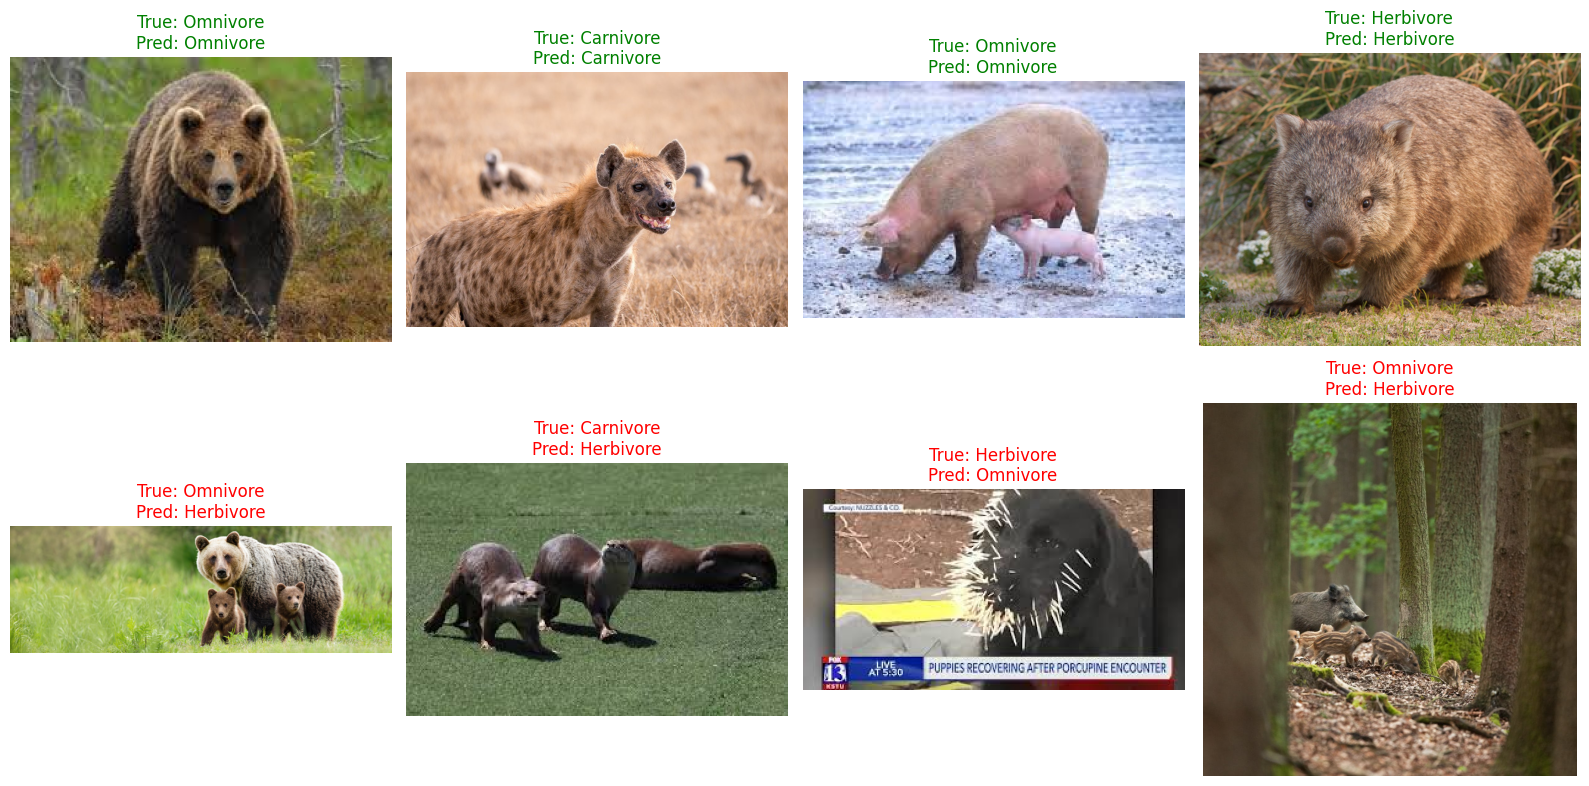

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# find some correct and some wrong predictions
correct_idx = np.where(predictions == y_test)[0]
wrong_idx = np.where(predictions != y_test)[0]

# pick a few of each
show_correct = correct_idx[:4]
show_wrong = wrong_idx[:4]
show_idx = list(show_correct) + list(show_wrong)

plt.figure(figsize=(16, 8))
for i, idx in enumerate(show_idx):
    img = Image.open(test_paths[idx])
    true_label = label_encoder.classes_[y_test[idx]]
    pred_label = label_encoder.classes_[predictions[idx]]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()
new_image_path = list(uploaded.keys())[0]
print("Uploaded:", new_image_path)

Saving images (3).jpeg to images (3) (1).jpeg
Saving images (4).jpeg to images (4) (1).jpeg
Saving images (5).jpeg to images (5) (1).jpeg
Saving images (6).jpeg to images (6) (1).jpeg
Saving images (7).jpeg to images (7) (1).jpeg
Saving images (8).jpeg to images (8) (1).jpeg
Saving images (9).jpeg to images (9) (1).jpeg
Saving images (10).jpeg to images (10) (1).jpeg
Saving images (11).jpeg to images (11) (1).jpeg
Uploaded: images (3) (1).jpeg


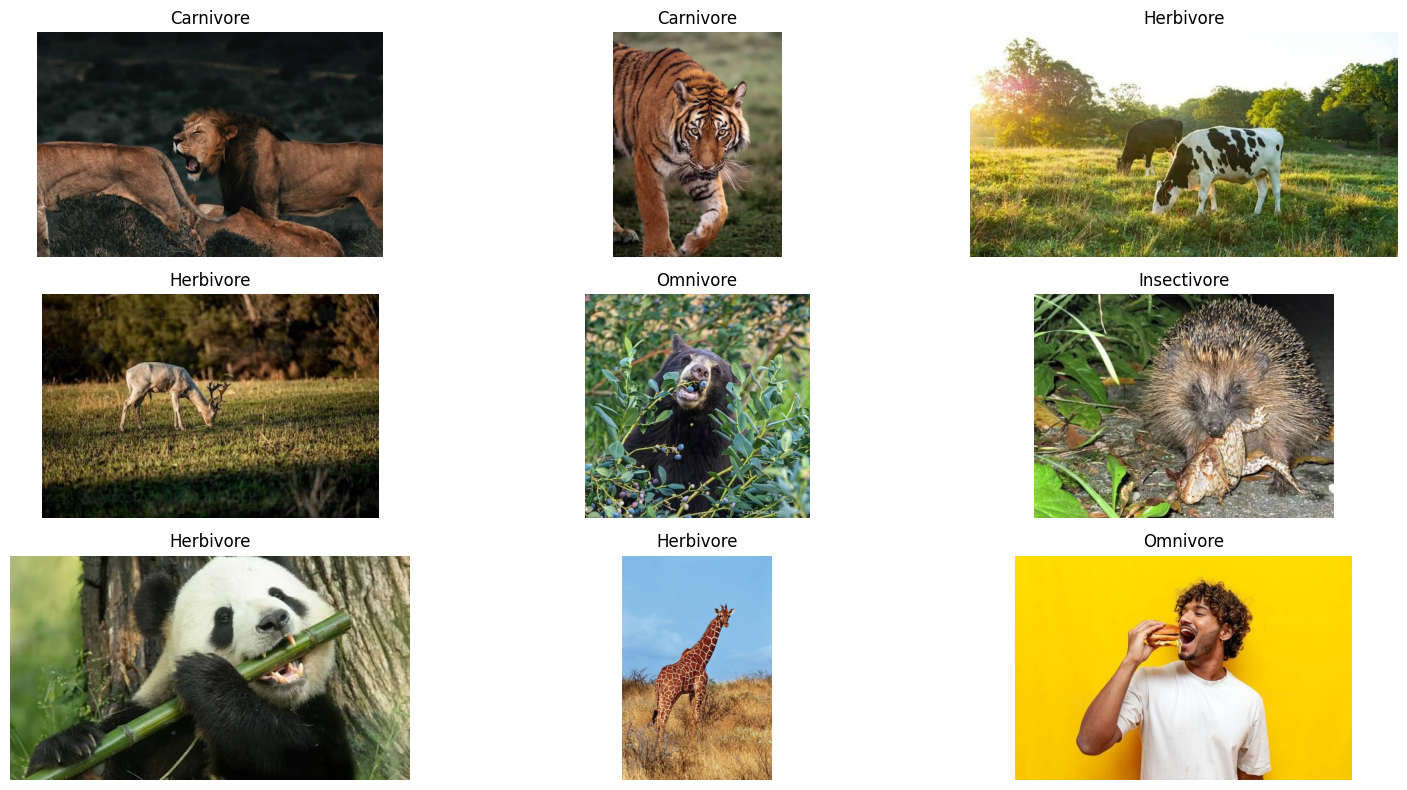

In [ ]:
plt.figure(figsize=(16, 8))

for i, filename in enumerate(uploaded.keys()):
    img = Image.open(filename).convert("RGB")
    img_processed = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feature = model.encode_image(img_processed).cpu().numpy()

    prediction = classifier.predict(feature)
    predicted_label = label_encoder.classes_[prediction[0]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(predicted_label)

plt.tight_layout()
plt.show()